# Day 24 - Customer Order Sampling and Statistical Inference

## 분석 목적

고객 주문 데이터를 이용하여 표본추출과 표본평균의 변동을 확인하고,
표본분포, 중심극한정리, 표준오차, 신뢰구간의 의미를 이해한다.

현재 데이터는 30명의 가상 고객 데이터이므로
실제 외부 모집단에 결과를 일반화하는 것이 목적은 아니다.

통계 개념 학습을 위해 현재 데이터를
연습용 모집단 또는 관측 표본으로 가정하여 분석한다.

## 분석 질문

1. 같은 데이터에서 표본을 다시 뽑으면 평균 주문 수는 얼마나 달라지는가?
2. 표본평균을 반복해서 계산하면 어떤 분포가 만들어지는가?
3. 표본 수가 커지면 평균 추정의 흔들림은 어떻게 변하는가?
4. 표준편차와 표준오차는 어떻게 다른가?
5. 평균 주문 수를 하나의 숫자가 아니라 신뢰구간으로 표현하면 무엇이 달라지는가?

## 주요 개념

### 추론통계

표본에서 계산한 통계량을 이용하여
모집단의 특성을 추정하고 불확실성을 표현하는 방법이다.

### 표본분포

같은 크기의 표본을 반복해서 추출하고
매번 계산한 통계량들이 이루는 분포다.

### 중심극한정리

일정한 조건에서 표본 크기가 충분히 커지면
표본평균의 분포는 정규분포에 가까워지는 경향이 있다.

원본 데이터 자체가 정규분포로 변하는 것은 아니다.

### 표준오차

표본을 다시 뽑았을 때
표본평균이 얼마나 달라질지를 나타내는 값이다.

SE = s / √n

### 신뢰구간

하나의 점추정값만 제시하지 않고
추정의 불확실성을 범위로 함께 표현한다.

In [1]:
# 라이브러리와 경로
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t


project_root = Path.cwd().parent

input_path = (
    project_root
    / "outputs"
    / "customer_order_mini_project.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(input_path)
print(input_path.exists())

d:\Study\Projects\00_foundation_review\outputs\customer_order_mini_project.csv
True


In [2]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(
    df.shape
)

print(
    df.head()
)

(30, 18)
   customer_id customer_name   region grade  total_order_count  \
0            1           Kim    Seoul   VIP                  9   
1            5           Han    Seoul   VIP                  8   
2            6          Jung    Busan  GOLD                  7   
3            9          Yoon  Daejeon   VIP                  6   
4           25           Bae  Incheon   VIP                  6   

   paid_order_count  cancelled_order_count  paid_rate first_order_date  \
0                 9                      0      100.0       2026-01-15   
1                 8                      0      100.0       2025-12-20   
2                 6                      1       85.7       2026-01-05   
3                 6                      0      100.0       2026-01-07   
4                 6                      0      100.0       2026-01-12   

  last_order_date data_reference_date  active_period_days  \
0      2026-07-30          2026-07-31               196.0   
1      2026-07-31          

In [4]:
# 분석 변수 확인
order_count = (
    df[
        "total_order_count"
    ]
)

print(
    order_count.head()
)

print(
    order_count.isna().sum()
)

0    9
1    8
2    7
3    6
4    6
Name: total_order_count, dtype: int64
0


## 실습 1 - 현재 데이터를 연습용 모집단으로 사용

표본분포를 실제로 확인하기 위해
현재 30명의 고객 데이터를 연습용 모집단이라고 가정한다.

이 모집단에서 일부 고객을 반복해서 무작위 추출하고
매번 평균 주문 수를 계산한다.

실제 회사의 전체 고객 모집단을 의미하는 것은 아니다.

In [5]:
population_count = len(
    order_count
)

population_mean = (
    order_count.mean()
)

population_std = (
    order_count.std(ddof = 0)
)

print(
    "연습용 모집단 고객 수:",
    population_count
)

print(
    "연습용 모집단 평균:",
    population_mean
)

print(
    "연습용 모집단 표준편차:",
    population_std
)


연습용 모집단 고객 수: 30
연습용 모집단 평균: 3.466666666666667
연습용 모집단 표준편차: 2.334285520001546


## 무작위 표본추출

pandas의 sample()은 DataFrame이나 Series에서
무작위로 일부 행을 선택한다.

head()는 앞에서부터 데이터를 가져오므로
무작위 표본추출과는 다르다.

random_state는 같은 표본을 다시 재현하기 위해 사용한다.

In [6]:
# 한 번 표본추출
sample_size = 10

sample = (
    order_count
    .sample(
        n = sample_size,
        random_state = 42
    )
)

print(
    sample
)

print(
    "표본평균:",
    sample.mean()
)

print(
    "연습용 모집단 평균:",
    population_mean
)

27    2
15    4
23    3
17    2
8     4
9     5
28    2
24    3
12    3
0     9
Name: total_order_count, dtype: int64
표본평균: 3.7
연습용 모집단 평균: 3.466666666666667


## 실습 2 - 표본평균을 반복해서 계산

한 번의 표본평균만 보면
표본을 다시 뽑았을 때 얼마나 달라지는지 알 수 없다.

따라서 같은 크기의 표본을 반복해서 추출하고
매번 평균을 저장한다.

이번 실습에서는 표본 크기를 10명으로 고정하고
1,000번 반복한다.

In [10]:
# 반복 표본추출
sample_size = 10
repeat_count = 1000

sample_means = []

for i in range(repeat_count):
    sample_mean = (
        order_count.sample(
            n = sample_size,
            replace = True,
            random_state = i
        )
    ).mean()

    sample_means.append(
        sample_mean
    )

sample_means_df = pd.DataFrame(
    {
        "sample_mean" : sample_means
    }
)

print(
    sample_means_df.head()
)

print(
    sample_means_df.shape
)



   sample_mean
0          3.9
1          4.6
2          3.3
3          3.3
4          3.8
(1000, 1)


In [11]:
# 표본평균 저장
sample_means_output_path = (
    output_dir
    / "customer_order_sample_means.csv"
)

sample_means_df.to_csv(
    sample_means_output_path,
    index = False
)

print(
    sample_means_output_path.exists()
)

True


In [12]:
# 표본분포 요약
sampling_mean = (
    sample_means_df[
        "sample_mean"
    ].mean()
)

sampling_std = (
    sample_means_df[
        "sample_mean"
    ].std()
)

print(
    "연습용 모집단 평균:",
    population_mean
)

print(
    "표본평균들의 평균:",
    sampling_mean
)

print(
    "표본평균들의 표준편차:",
    sampling_std
)

연습용 모집단 평균: 3.466666666666667
표본평균들의 평균: 3.4773
표본평균들의 표준편차: 0.7464126485007082


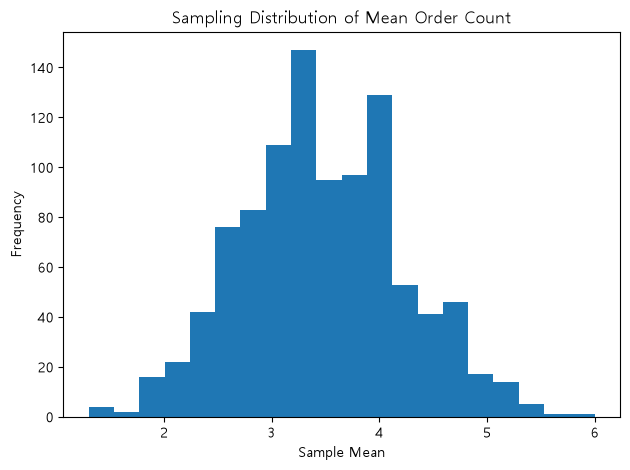

In [14]:
figure_path = (
    output_dir
    / "customer_order_sampling_distribution.png"
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

sample_means_df[
    "sample_mean"
].plot.hist(
    bins = 20
)

plt.title(
    "Sampling Distribution of Mean Order Count"
)

plt.xlabel(
    "Sample Mean"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

## 표준편차와 표준오차

표준편차는 개별 고객 주문 수의 퍼짐을 나타낸다.

표준오차는 표본을 반복 추출했을 때
표본평균이 얼마나 흔들릴지를 나타낸다.

따라서 두 값은 같은 의미가 아니다.

In [15]:
# 이론적 표준오차와 시뮬레이션 비교
theoretical_se = (
    population_std
    / (
        sample_size ** 0.5
    )
)

simulated_se = (
    sample_means_df[
        "sample_mean"
    ].std()
)

print(
    "이론적 표준오차:",
    theoretical_se
)

print(
    "시뮬레이션 표준오차:",
    simulated_se
)

이론적 표준오차: 0.7381658952355418
시뮬레이션 표준오차: 0.7464126485007082


## 표본 수와 표준오차

표준오차는

SE = s / √n

구조이므로 표본 수 n이 증가할수록 작아진다.

즉 더 많은 관측값을 사용하면
평균 추정의 흔들림이 줄어드는 경향이 있다.

In [17]:
# 표본 수별 표준오차
sample_sizes = [
    5,
    10,
    20,
    30
]

standard_errors = []

for n in (sample_sizes) :
    standard_error = (
        population_std
        /(
            n ** 0.5
        )
    )

    standard_errors.append(
        standard_error
    )

standard_error_df = pd.DataFrame(
    {
        "sample_size" : sample_sizes,
        "standard_error" : standard_errors
    }
)

print(
    standard_error_df
)

   sample_size  standard_error
0            5        1.043924
1           10        0.738166
2           20        0.521962
3           30        0.426180


In [18]:
# 표준오차 저장
standard_error_output_path = (
    output_dir
    / "customer_order_standard_error_by_sample_size.csv"
)

standard_error_df.to_csv(
    standard_error_output_path,
    index=False
)

print(
    standard_error_output_path.exists()
)

True


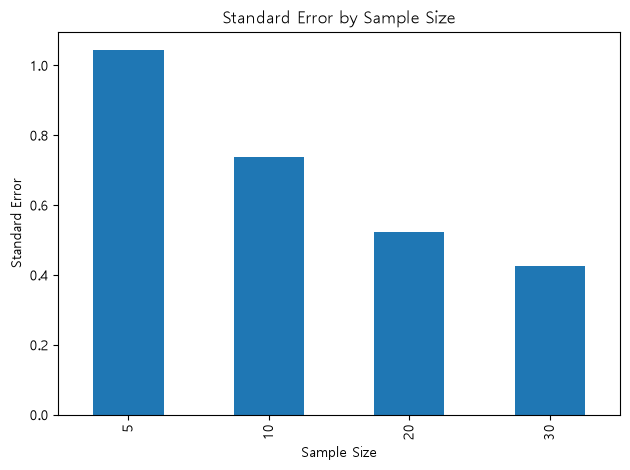

In [19]:
# 표본 수별 표준오차 그래프
figure_path = (
    output_dir
    / "customer_order_standard_error_by_sample_size.png"
)

standard_error_df.plot.bar(
    x="sample_size",
    y="standard_error",
    legend=False
)

plt.title(
    "Standard Error by Sample Size"
)

plt.xlabel(
    "Sample Size"
)

plt.ylabel(
    "Standard Error"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 실습 3 - 평균 주문 수의 신뢰구간

이번에는 현재 30명의 고객 데이터를
가상의 더 큰 고객 집단에서 관찰한 하나의 표본이라고 가정한다.

이 가정은 추론통계 학습을 위한 것이며
실제 외부 모집단에 결과를 일반화할 수 있다는 의미는 아니다.

표본평균을 점추정값으로 사용하고
표준오차와 t분포 임계값을 이용해 95% 신뢰구간을 계산한다.

In [ ]:
# 평균, 표준편차, 표준오차
sample_n = len(
    order_count
)

sample_mean = (
    order_count
    .mean()
)

sample_std = (
    order_count
    .std(ddof = 1)
)

standard_error = (
    sample_std
    / (
        sample_n ** 0.5
    )
)

print(
    "표본 수:",
    sample_n
)

print(
    "표본평균:",
    sample_mean
)

print(
    "표본 표준편차:",
    sample_std
)

print(
    "표준오차:",
    standard_error
)

표본 수: 30
표본평균: 3.466666666666667
표본 표준편차: 2.3741907272153604
표준오차: 0.43346593903848246


In [21]:
# t 임계값
critical_value = (
    t.ppf(
        0.975,
        df = sample_n -1
    )
)

print(
    "t 임계값:",
    critical_value
)

t 임계값: 2.045229642132704


In [22]:
# 95% 신뢰구간
margin_of_error = (
    critical_value
    * standard_error
)

ci_lower = (
    sample_mean
    - margin_of_error
)

ci_upper = (
    sample_mean
    + margin_of_error
)

print(
    "표본평균:",
    sample_mean
)

print(
    "오차범위:",
    margin_of_error
)

print(
    "95% 신뢰구간:",
    ci_lower,
    "~",
    ci_upper
)

표본평균: 3.466666666666667
오차범위: 0.8865373873763919
95% 신뢰구간: 2.580129279290275 ~ 4.353204054043059


In [23]:
# 추론 결과 요약표
inference_summary_df = pd.DataFrame(
    {
        "metric": [
            "sample_size",
            "sample_mean",
            "sample_std",
            "standard_error",
            "critical_value",
            "margin_of_error",
            "ci_lower",
            "ci_upper",
        ],
        "value": [
            sample_n,
            sample_mean,
            sample_std,
            standard_error,
            critical_value,
            margin_of_error,
            ci_lower,
            ci_upper,
        ],
    }
)

print(
    inference_summary_df
)

            metric      value
0      sample_size  30.000000
1      sample_mean   3.466667
2       sample_std   2.374191
3   standard_error   0.433466
4   critical_value   2.045230
5  margin_of_error   0.886537
6         ci_lower   2.580129
7         ci_upper   4.353204


In [24]:
# 요약표 저장
inference_output_path = (
    output_dir
    / "customer_order_inference_summary.csv"
)

inference_summary_df.to_csv(
    inference_output_path,
    index=False
)

print(
    inference_output_path.exists()
)

True


## 핵심 결과

### 1. 표본분포

표본 크기를 10명으로 두고
고객을 반복 추출하여 표본평균의 분포를 확인했다.

연습용 모집단 평균:
[실행 결과 입력]

표본평균들의 평균:
[실행 결과 입력]

표본평균들의 표준편차:
[실행 결과 입력]

표본을 바꿀 때마다 평균은 조금씩 달라졌지만,
반복된 표본평균들은 연습용 모집단 평균 주변에 분포했다.


### 2. 표준편차와 표준오차

개별 고객 주문 수의 표준편차:
[실행 결과 입력]

표본평균의 표준오차:
[실행 결과 입력]

표준편차는 고객 간 주문 수 차이를 나타내고,
표준오차는 평균 주문 수 추정값의 흔들림을 나타내므로
두 값은 서로 다른 의미를 가진다.


### 3. 표본 수의 영향

표본 수가 증가할수록 표준오차가 감소했다.

이는 더 많은 고객을 관찰할수록
평균 추정의 불확실성이 줄어드는 것을 의미한다.


### 4. 평균 주문 수 신뢰구간

표본평균:
[실행 결과 입력]

95% 신뢰구간:
[하한] ~ [상한]

신뢰구간은 평균을 하나의 숫자로만 제시하는 대신
추정의 불확실성을 범위로 함께 표현한다.


### 5. 분석 한계

현재 고객 30명은 Day 20에서 생성한 가상 데이터이며,
실제 더 큰 고객 모집단에서 무작위 추출된 표본이 아니다.

따라서 이번 신뢰구간을 실제 시장이나 고객 모집단에
일반화해서는 안 된다.

이번 분석의 목적은 표본추출, 표본분포,
표준오차와 신뢰구간의 계산 원리를 이해하는 것이다.